In [2]:
from typing import Dict, Tuple, List, Optional, Callable
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Consistent color definitions used across SynOmics visualizations
DATA_COLORS = {"real": "#4c72b0", "synthetic": "#dd8452"}
PVAL_BIN_COLORS_DEFAULT = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"]  # red, orange, blue, gray


def _shorten_hallmark_term(term: str) -> str:
    """
    Convert MSigDB Hallmark term into a shorter pathway label for y-axis.

    Args:
        term (str): Raw Hallmark term.

    Returns:
        str: Shortened label.

    Raises:
        ValueError: If term is empty.
    """
    if term is None or str(term).strip() == "":
        raise ValueError("term must be a non-empty string.")

    t = str(term).strip().upper()
    if t.startswith("HALLMARK_"):
        t = t.replace("HALLMARK_", "", 1)

    mapping = {
        "INTERFERON_ALPHA_RESPONSE": r"IFN$\alpha$",
        "INTERFERON_GAMMA_RESPONSE": r"IFN$\gamma$",
        "IL6_JAK_STAT3_SIGNALING": "IL6–JAK–STAT3",
        "INFLAMMATORY_RESPONSE": "Inflammatory",
        "TGF_BETA_SIGNALING": r"TGF-$\beta$",
        "DNA_REPAIR": "DNA repair",
        "ALLOGRAFT_REJECTION": "Allograft rejection",
        "COMPLEMENT": "Complement",
        "EPITHELIAL_MESENCHYMAL_TRANSITION": "Epithelial",
        "WNT_BETA_CATENIN_SIGNALING": r"WNT/$\beta$-catenin",
    }
    return mapping.get(t, t.replace("_", " ").title())


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip whitespace from dataframe column names.

    Args:
        df (pd.DataFrame): Input dataframe.

    Returns:
        pd.DataFrame: Dataframe with stripped columns.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _resolve_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """
    Resolve a column name from a list of candidate aliases.

    Args:
        df (pd.DataFrame): Input dataframe.
        candidates (List[str]): Candidate column names in priority order.

    Returns:
        Optional[str]: Matched column name if found.
    """
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def plot_pathway(
    ssGSEA_results: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str],
    highlight_pathways: Optional[List[str]] = None,
    term_col: str = "Term",
    nes_col: str = "NES",
    fdr_col: str = "FDR q-val",
    shorten_terms: bool = True,
    term_formatter: Optional[Callable[[str], str]] = None,
    pval_bin_colors: List[str] = PVAL_BIN_COLORS_DEFAULT,
    dataset_colors: Optional[Dict[str, str]] = None,
    figsize: Optional[Tuple[float, float]] = None,
    fig_width_min: float = 14.0,
    bubble_size: float = 170.0,
    title_pad: float = 14.0,
    dataset_strip_y: float = 1.01,
    dataset_strip_lw: float = 4.0,
    dataset_strip_pad: float = 0.0,
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    allow_column_aliases: bool = True,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:
    """
    Plot a pathway bubble scatter plot from ssGSEA/GSEA results (Term, NES, FDR q-val).

    Args:
        ssGSEA_results (Dict[str, pd.DataFrame]): Mapping dataset/model name -> DataFrame.
        ref_pathway_list (List[str]): Ordered list of pathways/terms to show on y-axis.
        highlight_pathways (Optional[List[str]]): Pathways to highlight (bold + colored y-ticks).
        term_col (str): Preferred column name for term/pathway.
        nes_col (str): Preferred column name for NES.
        fdr_col (str): Preferred column name for FDR q-values.
        shorten_terms (bool): If True, shorten Hallmark term labels for readability.
        term_formatter (Optional[Callable[[str], str]]): Custom formatting function for y-axis labels.
            If None and shorten_terms=True, uses _shorten_hallmark_term.
        pval_bin_colors (List[str]): Colors for q-value bins [q<0.01, 0.01≤q<0.05, 0.05≤q<0.25, q≥0.25].
        dataset_colors (Optional[Dict[str, str]]): Mapping dataset name -> strip color under title.
        figsize (Optional[Tuple[float, float]]): If provided, use this figure size (inches) directly.
        fig_width_min (float): Minimum figure width if figsize is None.
        bubble_size (float): Scatter marker size.
        title_pad (float): Padding (points) between axis and title (increase to lift title up).
        dataset_strip_y (float): Strip y position in axes coordinates (1.0 is top border).
        dataset_strip_lw (float): Strip line width.
        dataset_strip_pad (float): Additional vertical offset added to dataset_strip_y (axes coords).
        show (bool): If True, calls plt.show().
        save_path (Optional[str]): If provided, saves figure to path.
        return_dataframe (bool): If True, return plotting dataframe.
        allow_column_aliases (bool): If True, attempt to resolve common aliases for NES/FDR columns.

    Returns:
        Tuple[plt.Figure, Optional[pd.DataFrame]]: Figure and plotting dataframe.

    Raises:
        ValueError: If ssGSEA_results is empty.
        ValueError: If ref_pathway_list is empty.
        ValueError: If no dataset contains required columns and at least one requested pathway.
    """
    if not ssGSEA_results:
        raise ValueError("ssGSEA_results must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")
    if highlight_pathways is None:
        highlight_pathways = []

    if term_formatter is None and shorten_terms:
        term_formatter = _shorten_hallmark_term

    datasets = list(ssGSEA_results.keys())
    all_data_to_plot: List[pd.DataFrame] = []
    found_any = False

    term_candidates = [term_col, "term", "Pathway", "pathway"]
    nes_candidates = [nes_col, "Diff_NES", "NES ", "nes"]
    fdr_candidates = [fdr_col, "FDR q-val ", "FDR_qval", "FDR", "qvalue", "q-value", "adj_pvalues", "padj"]

    for ds_name in datasets:
        df_ds = ssGSEA_results.get(ds_name)
        if df_ds is None or not isinstance(df_ds, pd.DataFrame):
            warnings.warn(f"Skipping {ds_name}: not a pandas DataFrame.")
            continue

        df_ds = _normalize_columns(df_ds)

        if allow_column_aliases:
            term_resolved = _resolve_column(df_ds, term_candidates)
            nes_resolved = _resolve_column(df_ds, nes_candidates)
            fdr_resolved = _resolve_column(df_ds, fdr_candidates)
        else:
            term_resolved = term_col if term_col in df_ds.columns else None
            nes_resolved = nes_col if nes_col in df_ds.columns else None
            fdr_resolved = fdr_col if fdr_col in df_ds.columns else None

        missing = []
        if term_resolved is None:
            missing.append(term_col)
        if nes_resolved is None:
            missing.append(nes_col)
        if fdr_resolved is None:
            missing.append(fdr_col)

        if missing:
            warnings.warn(
                f"Skipping {ds_name}: missing required columns: {missing}. "
                f"Available columns: {list(df_ds.columns)}"
            )
            continue

        sub_df = df_ds[df_ds[term_resolved].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            warnings.warn(f"Skipping {ds_name}: none of ref_pathway_list terms were found.")
            continue

        found_any = True

        sub_df = sub_df.rename(
            columns={
                term_resolved: "Term",
                nes_resolved: "NES",
                fdr_resolved: "FDR_qval",
            }
        )
        sub_df["Dataset"] = ds_name

        sub_df["NES"] = pd.to_numeric(sub_df["NES"], errors="coerce").fillna(0.0)
        sub_df["FDR_qval"] = pd.to_numeric(sub_df["FDR_qval"], errors="coerce")

        sub_df["-log10(qvalue)"] = -np.log10(sub_df["FDR_qval"].clip(lower=np.nextafter(0, 1)))

        all_data_to_plot.append(sub_df[["Dataset", "Term", "NES", "FDR_qval", "-log10(qvalue)"]])

    if not found_any:
        raise ValueError("No dataset contained required columns and at least one requested pathway.")

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    present = set(df_plot["Term"].unique())
    y_terms = [p for p in ref_pathway_list if p in present]
    if not y_terms:
        raise ValueError("None of the pathways in ref_pathway_list were found after filtering.")

    # Display labels (shortened)
    if term_formatter is not None:
        y_labels = [term_formatter(t) for t in y_terms]
    else:
        y_labels = list(y_terms)

    mapping = {term: idx for idx, term in enumerate(y_terms)}
    y_pos = np.arange(len(y_terms))

    max_abs_nes = np.nanmax(np.abs(df_plot["NES"].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_nes) or max_abs_nes == 0:
        max_abs_nes = 1.0

    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["q<0.01", "0.01≤q<0.05", "0.05≤q<0.25", "q≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))

    df_plot["qvalue_bin"] = pd.cut(
        df_plot["FDR_qval"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )

    # n_cols = len(datasets)

    # if figsize is None:
    #     fig_width = max(3.5 * n_cols + 2, fig_width_min)
    #     fig_height = max(0.6 * len(y_terms) + 3, 7)
    #     figsize = (fig_width, fig_height)

    # fig, axes = plt.subplots(1, n_cols, figsize=figsize, sharey=True, sharex=True)
    # axes_list = [axes] if n_cols == 1 else list(axes.flat)

    n_rows, n_cols = 2, 3
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharey=True,
        sharex=True,
    )
    
    axes_list = axes.flatten()

    # plt.subplots_adjust(left=0.28, right=0.88, top=0.88, bottom=0.08, wspace=0.18)
    plt.subplots_adjust(
    left=0.30,
    right=0.86,
    top=0.92,
    bottom=0.08,
    wspace=0.25,
    hspace=0.30,
)

    for i, ds in enumerate(datasets[: len(axes_list)]):
        for j in range(len(datasets), len(axes_list)):
            axes_list[j].axis("off")
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        sub["y"] = sub["Term"].map(mapping)

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.tick_params(left=False, labelleft=False)
        else:
            bubble_colors = sub["qvalue_bin"].map(color_map).fillna("#cccccc")

            ax.scatter(
                x=sub["NES"],
                y=sub["y"],
                s=bubble_size,
                c=bubble_colors,
                edgecolor="k",
                linewidths=0.4,
                alpha=0.95,
                zorder=2,
            )

            ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_xlabel("NES", fontsize=9, labelpad=6)

            ax.set_yticks(y_pos)
            
            ax.set_ylim(-0.5, len(y_terms) - 0.5)
            ax.invert_yaxis()
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            # if i == 0:
            #     ax.set_yticklabels(y_labels, fontsize=9)
            #     ax.tick_params(axis="y", which="major", pad=6)
            #     for label in ax.get_yticklabels():
            #         if label.get_text() in [(term_formatter(t) if term_formatter else t) for t in highlight_pathways]:
            #             label.set_color(DATA_COLORS["real"])
            #             label.set_fontweight("bold")
            #         else:
            #             label.set_color("black")
            # else:
            #     ax.tick_params(left=False, labelleft=False)
            if i % n_cols == 0:   # cột đầu tiên của mỗi hàng
                ax.set_yticks(y_pos)
                ax.set_yticklabels(y_labels, fontsize=9)
                ax.tick_params(axis="y", which="major", pad=6)
            
                highlight_labels = [
                    (term_formatter(t) if term_formatter else t)
                    for t in highlight_pathways
                ]
            
                for label in ax.get_yticklabels():
                    if label.get_text() in highlight_labels:
                        label.set_color(DATA_COLORS["real"])
                        label.set_fontweight("bold")
                    else:
                        label.set_color("black")
            else:
                ax.tick_params(left=False, labelleft=False)

        if dataset_colors is not None:
            strip_color = dataset_colors.get(ds, "#333333")
            y_strip = dataset_strip_y + dataset_strip_pad
            ax.plot(
                [0.08, 0.92],
                [y_strip, y_strip],
                transform=ax.transAxes,
                color=strip_color,
                lw=dataset_strip_lw,
                clip_on=False,
                solid_capstyle="round",
            )

    import matplotlib.patches as mpatches

    legend_patches = [mpatches.Patch(color=color_map[l], label=l) for l in bin_labels]
    axes_list[-1].legend(
        handles=legend_patches,
        title="FDR q-val",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)
    df_plot = df_plot[["Dataset", "Term", "NES", "FDR_qval", "-log10(qvalue)", "y", "qvalue_bin"]]

    return (fig, df_plot) if return_dataframe else (fig, None)

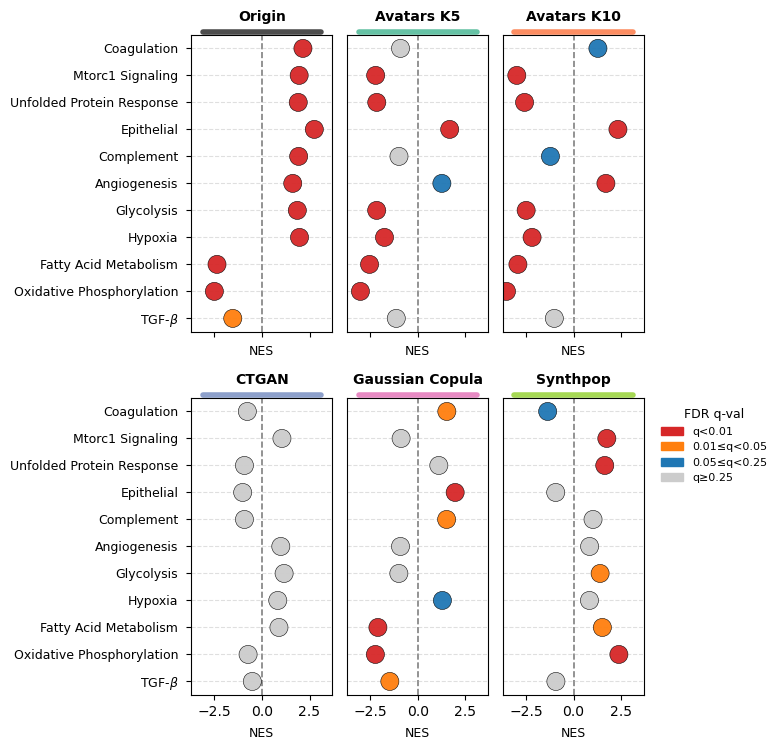

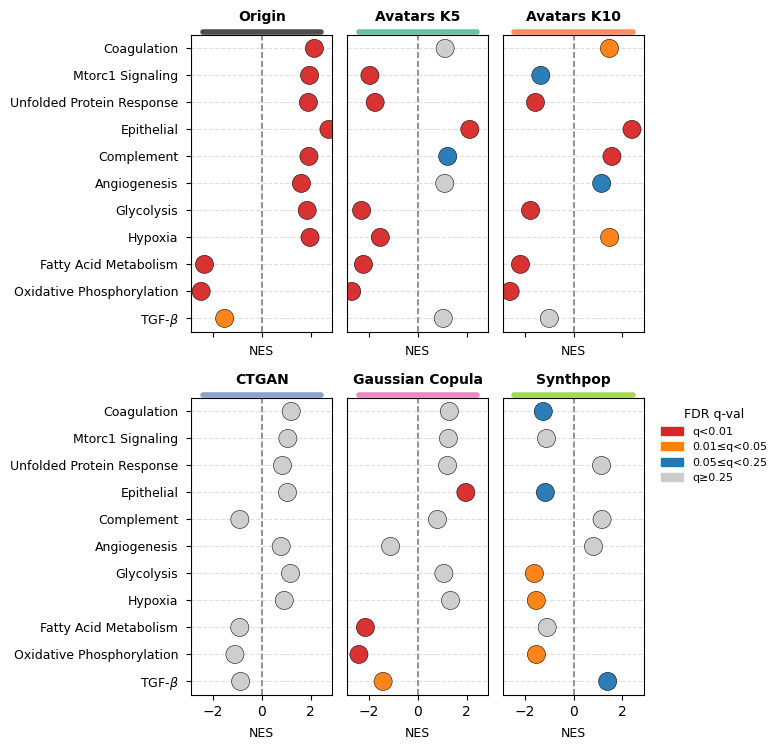

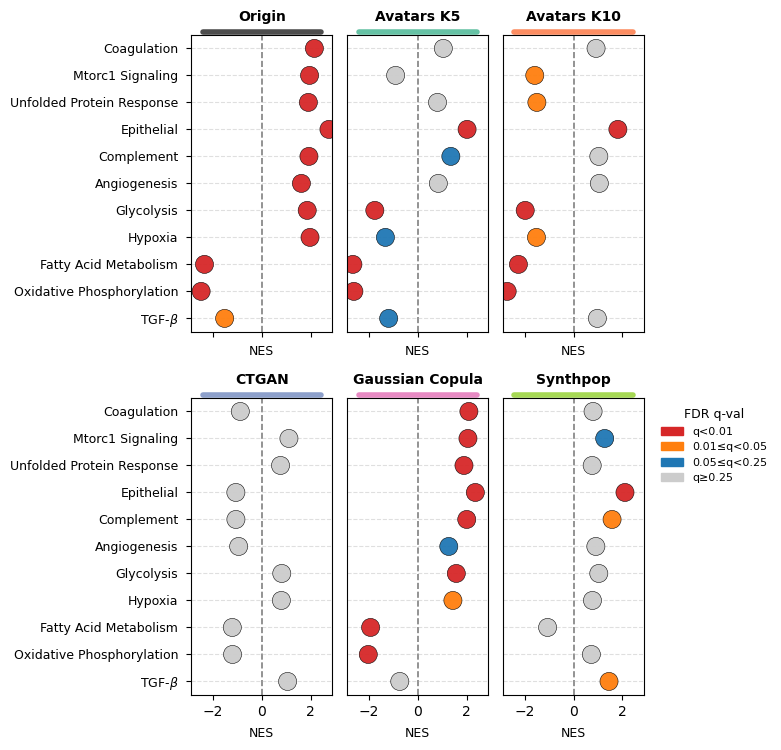

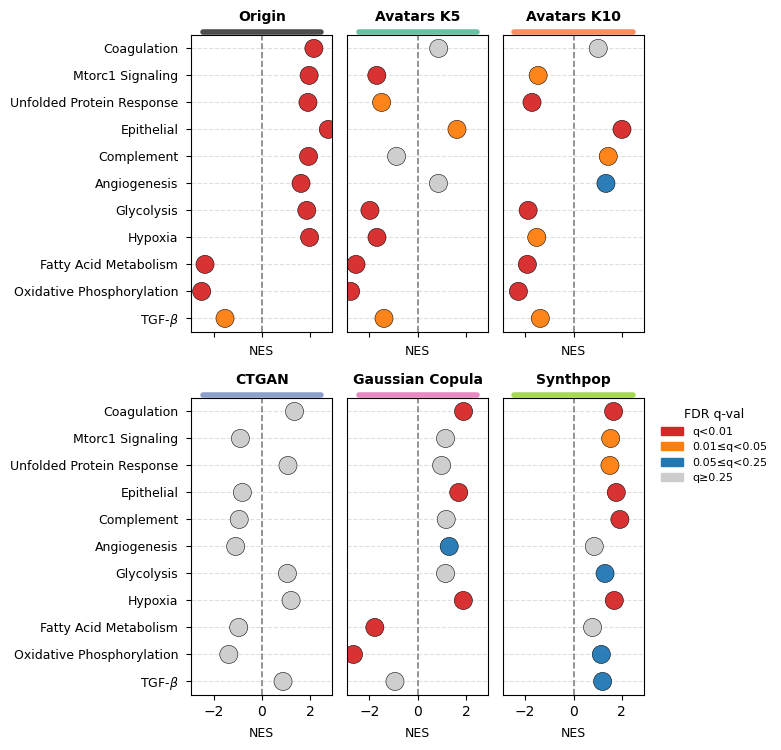

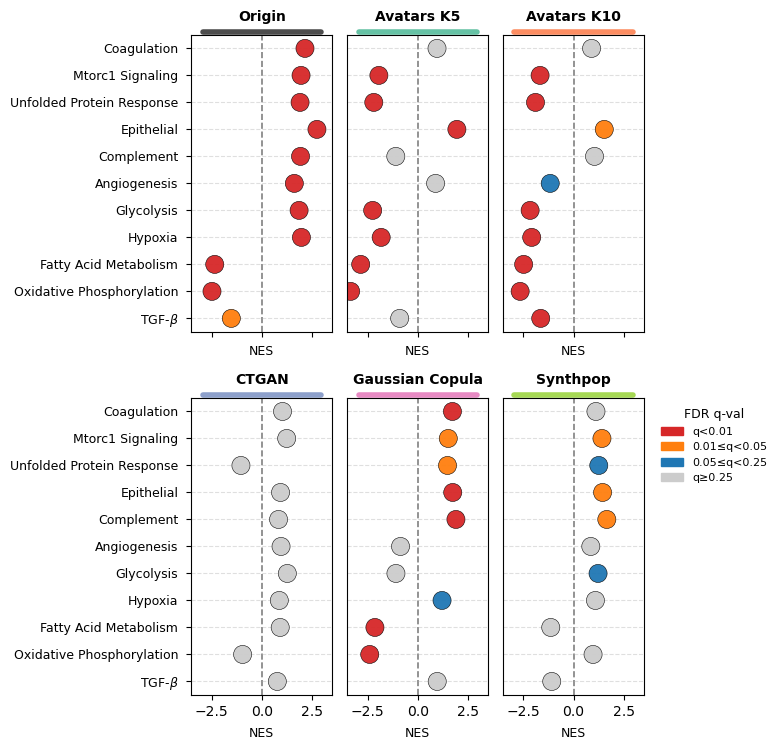

In [5]:
seeds = [0,1,2,3,42]
    # Dataset colors
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula":  "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}
for seed in seeds:
    Del9p21_dict = {}
    terms = [
       'HALLMARK_COAGULATION', 'HALLMARK_MTORC1_SIGNALING', 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
        'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_COMPLEMENT', 'HALLMARK_ANGIOGENESIS',
        'HALLMARK_GLYCOLYSIS', 'HALLMARK_HYPOXIA', 'HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
        'HALLMARK_TGF_BETA_SIGNALING'
    ]
    DataSeed_Path ={
        'avatarsk5': seed,
        'avatarsk10': seed,
        'ctgan': seed,
       'gaussiancopula': seed,
        'synthpop': seed
    }
    names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop']
    
    ori_del9p21 = pd.read_csv('../ccRCC/NarrowUtility/GSEA/Del9p21/Seed_42/GSEA_Origin.csv')
    Del9p21_dict['Origin']=ori_del9p21
    
    for i, tool in enumerate(names):
        dataname = list(DataSeed_Path.keys())[i]
        seed = list(DataSeed_Path.values())[i]
        gsea_res = pd.read_csv(f'../ccRCC/NarrowUtility/GSEA/Del9p21/Seed_{seed}/GSEA_{dataname}_{seed}.csv')
        gsea_res = gsea_res[gsea_res['Term'].isin(terms)][['Term','NES','FDR q-val']]
        Del9p21_dict[tool]=gsea_res

        
    fig, df_used = plot_pathway(
    ssGSEA_results=Del9p21_dict,
    ref_pathway_list=terms,
    dataset_colors=DATASET_COLORS,
    figsize=(9, 8),        # <-- bạn control kích thước
    title_pad=10,           # <-- nâng title lên (đỡ đụng strip)
    dataset_strip_pad=0.0, # <-- nâng strip lên thêm chút (axes coords)
    shorten_terms=True,     # <-- dùng _shorten_hallmark_term
    show=True,
    )
    # fig.savefig(f"Del9p213/Del9p21_BubblePlot_{seed}.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(f"Del9p213/Del9p21_BubblePlot_{seed}.pdf", dpi=300, bbox_inches="tight", facecolor="white")

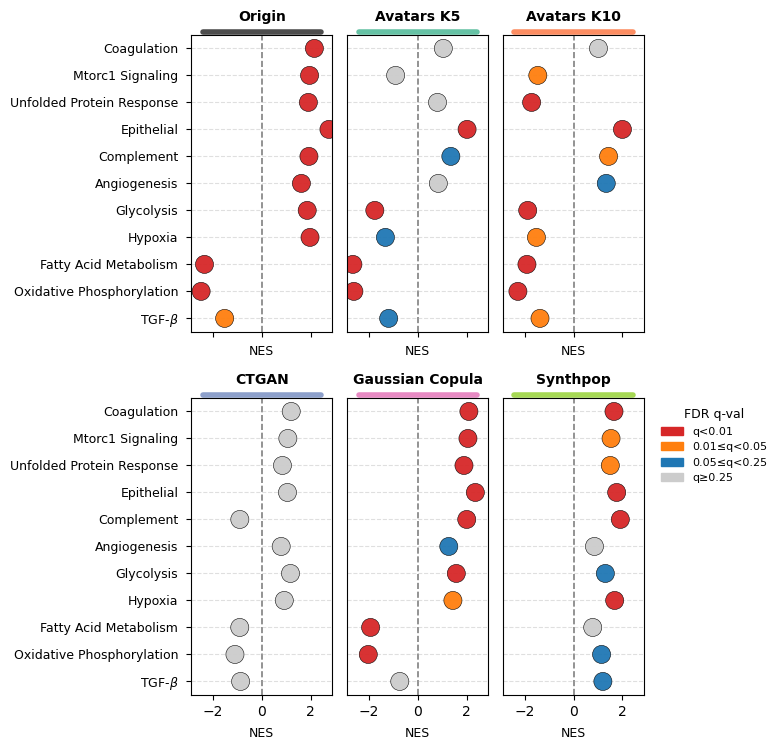

In [7]:
terms = [
   'HALLMARK_COAGULATION', 'HALLMARK_MTORC1_SIGNALING', 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_COMPLEMENT', 'HALLMARK_ANGIOGENESIS',
    'HALLMARK_GLYCOLYSIS', 'HALLMARK_HYPOXIA', 'HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_TGF_BETA_SIGNALING'
]
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula":  "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}
Del9p21_dict_2 = {}
DataSeed_Path ={
    'avatarsk5': 2,
    'avatarsk10': 3,
    'ctgan': 1,
   'gaussiancopula': 2,
    'synthpop': 3
}
ori_del9p21 = pd.read_csv('../ccRCC/NarrowUtility/GSEA/Del9p21/Seed_42/GSEA_Origin.csv')
Del9p21_dict_2['Origin']=ori_del9p21
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop']
for i, tool in enumerate(names):
    dataname = list(DataSeed_Path.keys())[i]
    seed = list(DataSeed_Path.values())[i]
    gsea_res = pd.read_csv(f'../ccRCC/NarrowUtility/GSEA/Del9p21/Seed_{seed}/GSEA_{dataname}_{seed}.csv')
    gsea_res = gsea_res[gsea_res['Term'].isin(terms)][['Term','NES','FDR q-val']]
    Del9p21_dict_2[tool]=gsea_res

fig, df_used = plot_pathway(
    ssGSEA_results=Del9p21_dict_2,
    ref_pathway_list=terms,
    dataset_colors=DATASET_COLORS,
    figsize=(9, 8),        # <-- bạn control kích thước
    title_pad=10,           # <-- nâng title lên (đỡ đụng strip)
    dataset_strip_pad=0.0, # <-- nâng strip lên thêm chút (axes coords)
    shorten_terms=True,     # <-- dùng _shorten_hallmark_term
    show=True,
)
# fig.savefig("Del9p213/Del9p21_BubblePlot_presentive.png", dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig("Del9p213/Del9p21_BubblePlot_presentive.pdf", dpi=300, bbox_inches="tight", facecolor="white")

In [1]:
from typing import Dict, Tuple, List, Optional, Callable
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Consistent color definitions used across SynOmics visualizations
DATA_COLORS = {"real": "#4c72b0", "synthetic": "#dd8452"}
PVAL_BIN_COLORS_DEFAULT = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"]  # red, orange, blue, gray


def _shorten_hallmark_term(term: str) -> str:
    """
    Convert MSigDB Hallmark term into a shorter pathway label for y-axis.
    """
    if term is None or str(term).strip() == "":
        raise ValueError("term must be a non-empty string.")

    t = str(term).strip().upper()
    if t.startswith("HALLMARK_"):
        t = t.replace("HALLMARK_", "", 1)

    mapping = {
        "INTERFERON_ALPHA_RESPONSE": r"IFN$\alpha$",
        "INTERFERON_GAMMA_RESPONSE": r"IFN$\gamma$",
        "IL6_JAK_STAT3_SIGNALING": "IL6–JAK–STAT3",
        "INFLAMMATORY_RESPONSE": "Inflammatory",
        "TGF_BETA_SIGNALING": r"TGF-$\beta$",
        "DNA_REPAIR": "DNA repair",
        "ALLOGRAFT_REJECTION": "Allograft rejection",
        "COMPLEMENT": "Complement",
        "EPITHELIAL_MESENCHYMAL_TRANSITION": "Epithelial",
        "WNT_BETA_CATENIN_SIGNALING": r"WNT/$\beta$-catenin",
    }
    return mapping.get(t, t.replace("_", " ").title())


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip whitespace from dataframe column names.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _resolve_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """
    Resolve a column name from a list of candidate aliases.
    """
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def plot_pathway(
    ssGSEA_results: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str],
    highlight_pathways: Optional[List[str]] = None,
    term_col: str = "Term",
    nes_col: str = "NES",
    fdr_col: str = "FDR q-val",
    shorten_terms: bool = True,
    term_formatter: Optional[Callable[[str], str]] = None,
    pval_bin_colors: List[str] = PVAL_BIN_COLORS_DEFAULT,
    dataset_colors: Optional[Dict[str, str]] = None,
    figsize: Optional[Tuple[float, float]] = None,
    fig_width_min: float = 14.0,
    bubble_size: float = 170.0,
    title_pad: float = 14.0,
    dataset_strip_y: float = 1.01,
    dataset_strip_lw: float = 4.0,
    dataset_strip_pad: float = 0.0,
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    allow_column_aliases: bool = True,
    vertical_jitter: float = 0.12,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:
    """
    Plot a pathway bubble scatter plot from ssGSEA/GSEA results (Term, NES, FDR q-val).

    NOTE: This version supports multiple rows per (Dataset, Term) (e.g. replicates/seeds).
    Points for the same Term are slightly jittered vertically to show variability across replicates.
    """

    if not ssGSEA_results:
        raise ValueError("ssGSEA_results must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")
    if highlight_pathways is None:
        highlight_pathways = []

    if term_formatter is None and shorten_terms:
        term_formatter = _shorten_hallmark_term

    datasets = list(ssGSEA_results.keys())
    all_data_to_plot: List[pd.DataFrame] = []
    found_any = False

    term_candidates = [term_col, "term", "Pathway", "pathway"]
    nes_candidates = [nes_col, "Diff_NES", "NES ", "nes"]
    fdr_candidates = [fdr_col, "FDR q-val ", "FDR_qval", "FDR", "qvalue", "q-value", "adj_pvalues", "padj"]

    for ds_name in datasets:
        df_ds = ssGSEA_results.get(ds_name)
        if df_ds is None or not isinstance(df_ds, pd.DataFrame):
            warnings.warn(f"Skipping {ds_name}: not a pandas DataFrame.")
            continue

        df_ds = _normalize_columns(df_ds)

        if allow_column_aliases:
            term_resolved = _resolve_column(df_ds, term_candidates)
            nes_resolved = _resolve_column(df_ds, nes_candidates)
            fdr_resolved = _resolve_column(df_ds, fdr_candidates)
        else:
            term_resolved = term_col if term_col in df_ds.columns else None
            nes_resolved = nes_col if nes_col in df_ds.columns else None
            fdr_resolved = fdr_col if fdr_col in df_ds.columns else None

        missing = []
        if term_resolved is None:
            missing.append(term_col)
        if nes_resolved is None:
            missing.append(nes_col)
        if fdr_resolved is None:
            missing.append(fdr_col)

        if missing:
            warnings.warn(
                f"Skipping {ds_name}: missing required columns: {missing}. "
                f"Available columns: {list(df_ds.columns)}"
            )
            continue

        sub_df = df_ds[df_ds[term_resolved].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            warnings.warn(f"Skipping {ds_name}: none of ref_pathway_list terms were found.")
            continue

        found_any = True

        sub_df = sub_df.rename(
            columns={
                term_resolved: "Term",
                nes_resolved: "NES",
                fdr_resolved: "FDR_qval",
            }
        )
        sub_df["Dataset"] = ds_name

        sub_df["NES"] = pd.to_numeric(sub_df["NES"], errors="coerce").fillna(0.0)
        sub_df["FDR_qval"] = pd.to_numeric(sub_df["FDR_qval"], errors="coerce")

        sub_df["-log10(qvalue)"] = -np.log10(sub_df["FDR_qval"].clip(lower=np.nextafter(0, 1)))

        all_data_to_plot.append(sub_df[["Dataset", "Term", "NES", "FDR_qval", "-log10(qvalue)"] + ([c for c in ["Seed"] if "Seed" in sub_df.columns])] if "Seed" in sub_df.columns else sub_df[["Dataset", "Term", "NES", "FDR_qval", "-log10(qvalue)"]])

    if not found_any:
        raise ValueError("No dataset contained required columns and at least one requested pathway.")

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    present = set(df_plot["Term"].unique())
    y_terms = [p for p in ref_pathway_list if p in present]
    if not y_terms:
        raise ValueError("None of the pathways in ref_pathway_list were found after filtering.")

    # Display labels (shortened)
    if term_formatter is not None:
        y_labels = [term_formatter(t) for t in y_terms]
    else:
        y_labels = list(y_terms)

    mapping = {term: idx for idx, term in enumerate(y_terms)}
    y_pos = np.arange(len(y_terms))

    max_abs_nes = np.nanmax(np.abs(df_plot["NES"].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_nes) or max_abs_nes == 0:
        max_abs_nes = 1.0

    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["q<0.01", "0.01≤q<0.05", "0.05≤q<0.25", "q≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))

    df_plot["qvalue_bin"] = pd.cut(
        df_plot["FDR_qval"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )

    n_rows, n_cols = 2, 3
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharey=True,
        sharex=True,
    )
    
    axes_list = axes.flatten()

    plt.subplots_adjust(
        left=0.30,
        right=0.86,
        top=0.92,
        bottom=0.08,
        wspace=0.25,
        hspace=0.30,
    )

    for i, ds in enumerate(datasets[: len(axes_list)]):
        # turn off any extra axes (ensure only once per iteration)
        for j in range(len(datasets), len(axes_list)):
            axes_list[j].axis("off")
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        # integer y mapping for terms
        sub["y"] = sub["Term"].map(mapping).astype(float)

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.tick_params(left=False, labelleft=False)
        else:
            # Vertical jitter: for each group of same y (term) distribute points
            jitter = float(vertical_jitter)
            offsets = np.zeros(len(sub))
            groups = sub.groupby("y").groups  # mapping y -> indices
            for yval, idxs in groups.items():
                indices = list(idxs)
                count = len(indices)
                if count <= 1:
                    continue
                # sort deterministically: by Seed if present else by NES
                if "Seed" in sub.columns:
                    order_df = sub.loc[indices].sort_values(by="Seed")
                else:
                    order_df = sub.loc[indices].sort_values(by="NES")
                offs = np.linspace(-jitter, jitter, count)
                for pos, idx in enumerate(order_df.index):
                    local_pos = sub.index.get_indexer([idx])[0]
                    offsets[local_pos] = offs[pos]

            sub["y_plot"] = sub["y"].values + offsets

            bubble_colors = sub["qvalue_bin"].map(color_map).fillna("#cccccc")

            ax.scatter(
                x=sub["NES"],
                y=sub["y_plot"],
                s=bubble_size,
                c=bubble_colors,
                edgecolor="k",
                linewidths=0.4,
                alpha=0.95,
                zorder=2,
            )

            ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_xlabel("NES", fontsize=9, labelpad=6)

            ax.set_yticks(y_pos)
            
            ax.set_ylim(-0.5, len(y_terms) - 0.5)
            ax.invert_yaxis()
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            if i % n_cols == 0:   # first column of each row shows y labels
                ax.set_yticks(y_pos)
                ax.set_yticklabels(y_labels, fontsize=9)
                ax.tick_params(axis="y", which="major", pad=6)
            
                highlight_labels = [
                    (term_formatter(t) if term_formatter else t)
                    for t in highlight_pathways
                ]
            
                for label in ax.get_yticklabels():
                    if label.get_text() in highlight_labels:
                        label.set_color(DATA_COLORS["real"])
                        label.set_fontweight("bold")
                    else:
                        label.set_color("black")
            else:
                ax.tick_params(left=False, labelleft=False)

        if dataset_colors is not None:
            strip_color = dataset_colors.get(ds, "#333333")
            y_strip = dataset_strip_y + dataset_strip_pad
            ax.plot(
                [0.08, 0.92],
                [y_strip, y_strip],
                transform=ax.transAxes,
                color=strip_color,
                lw=dataset_strip_lw,
                clip_on=False,
                solid_capstyle="round",
            )

    import matplotlib.patches as mpatches

    legend_patches = [mpatches.Patch(color=color_map[l], label=l) for l in bin_labels]
    axes_list[-1].legend(
        handles=legend_patches,
        title="FDR q-val",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)
    df_plot = df_plot[["Dataset", "Term", "NES", "FDR_qval", "-log10(qvalue)", "y", "qvalue_bin"]]

    return (fig, df_plot) if return_dataframe else (fig, None)

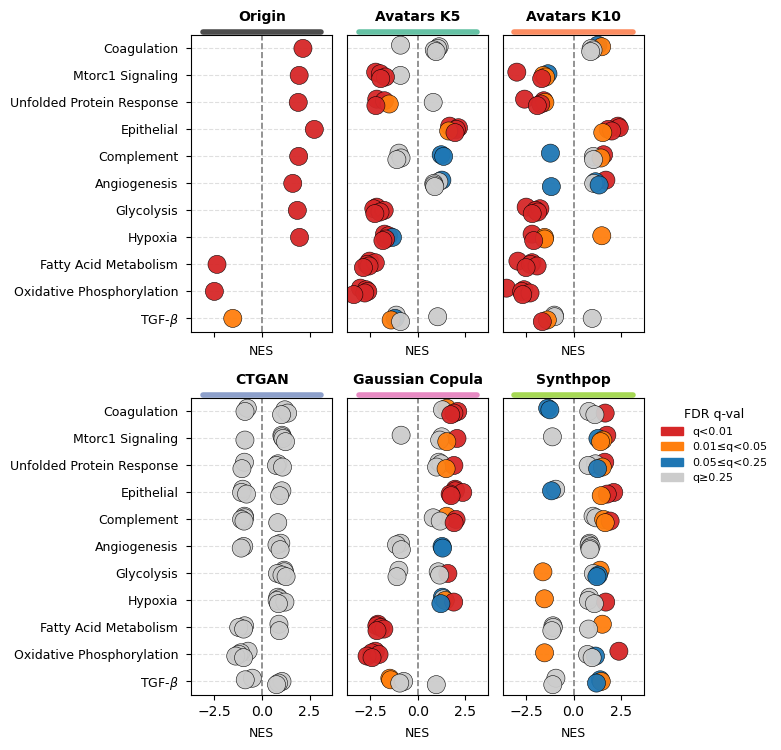

In [4]:
import pandas as pd
# from plot_pathway import plot_pathway

# Seeds to include (all will be combined in a single plot)
seeds = [0, 1, 2, 3, 42]

# Dataset colors for strip
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula":  "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

terms = [
   'HALLMARK_COAGULATION', 'HALLMARK_MTORC1_SIGNALING', 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_COMPLEMENT', 'HALLMARK_ANGIOGENESIS',
    'HALLMARK_GLYCOLYSIS', 'HALLMARK_HYPOXIA', 'HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_TGF_BETA_SIGNALING'
]

# Map short file names to display names
DataSeed_Path = {
    'avatarsk5': 'Avatars K5',
    'avatarsk10': 'Avatars K10',
    'ctgan': 'CTGAN',
    'gaussiancopula': 'Gaussian Copula',
    'synthpop': 'Synthpop'
}
datanames_short = list(DataSeed_Path.keys())
display_names = list(DataSeed_Path.values())

# Build dictionary where each dataset contains concatenated results across seeds, with a 'Seed' column
Del9p21_dict = {}

# Origin (single reference). If you have origin per seed, you can replicate similarly.
ori_del9p21 = pd.read_csv('../ccRCC/NarrowUtility/GSEA/Del9p21/Seed_42/GSEA_Origin.csv')
ori_del9p21 = ori_del9p21[ori_del9p21['Term'].isin(terms)][['Term', 'NES', 'FDR q-val']].copy()
ori_del9p21['Seed'] = 'origin'
Del9p21_dict['Origin'] = ori_del9p21

# For each dataset, read all seeds and concatenate
for short_name, display_name in DataSeed_Path.items():
    dfs = []
    for seed in seeds:
        try:
            gsea_res = pd.read_csv(f'../ccRCC/NarrowUtility/GSEA/Del9p21/Seed_{seed}/GSEA_{short_name}_{seed}.csv')
        except FileNotFoundError:
            # skip missing files with a warning
            print(f"Warning: file for {short_name} seed {seed} not found, skipping.")
            continue
        gsea_res = gsea_res[gsea_res['Term'].isin(terms)][['Term', 'NES', 'FDR q-val']].copy()
        gsea_res['Seed'] = int(seed)
        dfs.append(gsea_res)
    if dfs:
        combined = pd.concat(dfs, ignore_index=True)
        Del9p21_dict[display_name] = combined
    else:
        print(f"No data found for dataset {display_name} across seeds {seeds}.")

# Now call plot_pathway once to draw all seeds together
fig, df_used = plot_pathway(
    ssGSEA_results=Del9p21_dict,
    ref_pathway_list=terms,
    dataset_colors=DATASET_COLORS,
    figsize=(9, 8),        # adjust to taste
    title_pad=10,
    dataset_strip_pad=0.0,
    shorten_terms=True,
    show=True,
    vertical_jitter=0.12,   # controls separation of replicate dots vertically
)

# Save output
fig.savefig("Del9p213/Del9p21_BubblePlot_allSeeds.pdf", dpi=300, bbox_inches="tight", facecolor="white")